# 🚀 MISSION 4: THE NUMPY IMAGE PROCESSOR
### "Hacking Vision with Matrix Math"

[cite_start]**TUJUAN:** Membuktikan bahwa gambar digital hanyalah tumpukan angka (Tensor) yang bisa dimanipulasi dengan operasi matematika dasar tanpa aplikasi edit foto[cite: 209, 210].

---

### 🧠 KONSEP MATEMATIKA

Komputer melihat gambar sebagai Matriks. Kita akan membedah anatomi gambar RGB dan mengubahnya menggunakan Aljabar Linear.

**1. The Structure (Tensor 3D):**
[cite_start]Gambar berwarna adalah matriks 3-Dimensi dengan dimensi: $(Tinggi \times Lebar \times 3 \text{ Channel})$[cite: 215].
$$\text{Image}_{RGB} \in \mathbb{Z}^{H \times W \times 3}$$
[cite_start]Setiap pixel berisi kombinasi intensitas: **Red, Green, Blue**[cite: 216].

**2. The Manipulation (Slicing & Broadcasting):**
* [cite_start]**Crop (Memotong):** Mengambil sebagian kecil matriks menggunakan slicing `[y1:y2, x1:x2]`[cite: 224, 225].
* [cite_start]**Brightness (Kecerahan):** Menambahkan skalar ke seluruh elemen matriks secara serentak (Broadcasting) `img + n`[cite: 232, 233].

**3. The Final Boss (Grayscale via Dot Product):**
Mata manusia memiliki sensitivitas berbeda terhadap warna. [cite_start]Untuk mengubah RGB ke Hitam-Putih secara natural, kita menggunakan **Dot Product** antara vektor pixel dengan vektor bobot mata[cite: 235, 237].

$$\text{Pixel}_{Gray} = \vec{Pixel}_{RGB} \cdot \vec{Weight}$$
[cite_start]$$\text{Gray} = (R \cdot 0.299) + (G \cdot 0.587) + (B \cdot 0.114)$$ [cite: 236]

---

### 📝 INSTRUKSI TUGAS

1.  **Setup Data:**
    * Siapkan foto wajahmu sendiri (format `.jpg` atau `.png`).
    * [cite_start]Load gambar ke dalam NumPy array menggunakan `plt.imread()`[cite: 218, 255].
    * [cite_start]Cek dimensi matriksnya menggunakan `.shape`[cite: 219].

2.  **Operasi Geometris (Crop & Flip):**
    * [cite_start]Lakukan *slicing* untuk memotong area wajah/mata saja[cite: 257].
    * (Opsional) [cite_start]Balik gambar (*Flip*) menggunakan slicing `[::-1]`[cite: 228].

3.  **Operasi Aritmatika (Brightness):**
    * [cite_start]Terangkan gambar dengan menambahkan angka (misal `+50`) ke matriks gambar[cite: 258].

4.  **Operasi Aljabar (The Final Boss):**
    * Buat vektor bobot: `weights = np.array([0.299, 0.587, 0.114])`.
    * [cite_start]Lakukan operasi **Dot Product** (`@`) antara matriks gambar asli dengan vektor bobot untuk menghasilkan gambar *Grayscale*[cite: 259].

5.  **Visualisasi:**
    * Tampilkan gambar Asli dan gambar Grayscale berdampingan menggunakan `matplotlib`.

> **Constraint:** Jangan gunakan library edit foto instan (seperti OpenCV atau PIL). [cite_start]Gunakan murni operasi matriks NumPy[cite: 252].

In [23]:
import numpy as np
import matplotlib.pyplot as plt

In [24]:
image = np.zeros((3, 4, 3), dtype=int)
print(image)

print("---------------------------")

x = np.linspace(0, 255, 4) # (start, stop, num(jumlah))

# Syntax dasar untuk slicing adalah [start:stop:step]
# untuk array multidimensi [s:s:s, s:s:s, s:s:s]
image[1, :, 2] = x
print(image)

[[[0 0 0]
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  [0 0 0]]]
---------------------------
[[[  0   0   0]
  [  0   0   0]
  [  0   0   0]
  [  0   0   0]]

 [[  0   0   0]
  [  0   0  85]
  [  0   0 170]
  [  0   0 255]]

 [[  0   0   0]
  [  0   0   0]
  [  0   0   0]
  [  0   0   0]]]


In [25]:
# Mari kita akses pixel di pojok kiri atas (baris 0, kolom 0)
pixel_pojok = image[0, 0] 

print("Isi pixel di (0,0):", pixel_pojok)
print("Shape pixel:", pixel_pojok.shape)

Isi pixel di (0,0): [0 0 0]
Shape pixel: (3,)


In [26]:
def show_image(img):
    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.show()
    

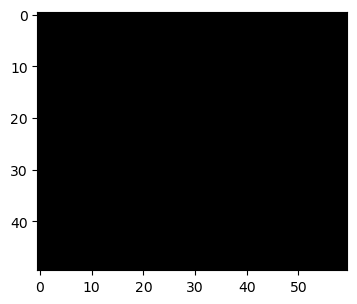

In [27]:
# buat image baru dengan array
height = 50
width = 60

img = np.zeros((height, width, 3), dtype=int)
show_image(img)

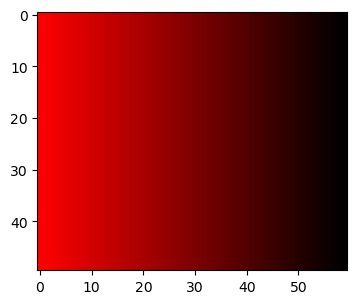

In [28]:
# gradasi merah (horizontal)

# copy image
img_red = img.copy()

# membuat array dengan value dari 255 - 0 sebanyak width
baris = np.linspace(255, 0, width)
img_red[:, :, 0] = baris

show_image(img_red)

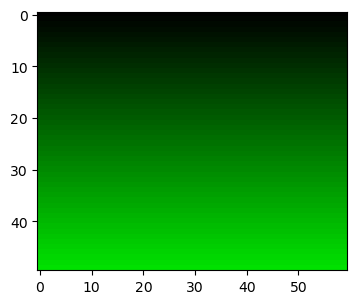

In [29]:
# gradasi hijau (vertikal)

# copy image
img_green = img.copy()

# membuat array dengan value dari 0 - 255 sebanyak height
kolom = np.linspace(0, 225, height)
img_green[:, :, 1] = kolom.reshape(-1, 1)
show_image(img_green)

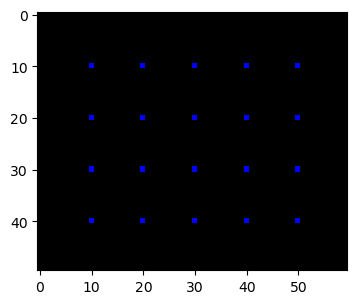

In [30]:
# biru kotak-kotak

# copy image
img_blue = img.copy()

# membirukan tiap 20 step
img_blue[10::10, 10::10, 2] = 255

show_image(img_blue)

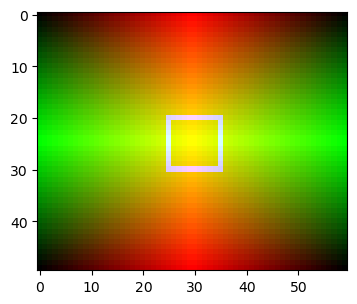

In [34]:
img_colab = img.copy()

half_width = int(width/2)
half_height = int(height/2)

red_1 = np.linspace(0, 255, half_width)
red_2 = np.linspace(255, 0, half_width)
img_colab[:, :half_width, 0] = red_1
img_colab[:, half_width:, 0] = red_2

green_1 = np.linspace(0, 255, half_height).reshape(-1, 1)
green_2 = np.linspace(255, 0, half_height).reshape(-1, 1)
img_colab[:half_height, :, 1] = green_1
img_colab[half_height:, :, 1] = green_2

blue = 255
img_colab[20:21, 25:36, 2] = blue
img_colab[30:31, 25:36, 2] = blue
img_colab[20:30, 25:26, 2] = blue
img_colab[20:30, 35:36, 2] = blue

show_image(img_colab)

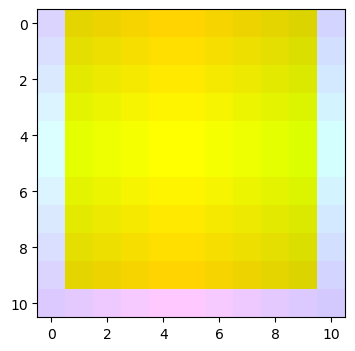

In [11]:
# crop image dengan slicing

img = img_colab.copy()

img_crop = img[20:31, 25:36]

show_image(img_crop)

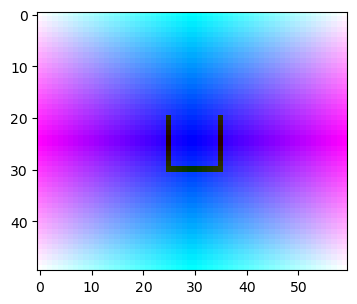

In [12]:
# invert image (negatif)
img = img_colab.copy()

img_invert = 255 - img

show_image(img_invert)

[[[ 0  0  0]
  [ 8  0  0]
  [17  0  0]
  ...
  [17  0  0]
  [ 8  0  0]
  [ 0  0  0]]

 [[ 0  0  0]
  [ 8  0  0]
  [17  0  0]
  ...
  [17  0  0]
  [ 8  0  0]
  [ 0  0  0]]

 [[ 0  0  0]
  [ 8  0  0]
  [17  0  0]
  ...
  [17  0  0]
  [ 8  0  0]
  [ 0  0  0]]

 ...

 [[ 0  0  0]
  [ 8  0  0]
  [17  0  0]
  ...
  [17  0  0]
  [ 8  0  0]
  [ 0  0  0]]

 [[ 0  0  0]
  [ 8  0  0]
  [17  0  0]
  ...
  [17  0  0]
  [ 8  0  0]
  [ 0  0  0]]

 [[ 0  0  0]
  [ 8  0  0]
  [17  0  0]
  ...
  [17  0  0]
  [ 8  0  0]
  [ 0  0  0]]]


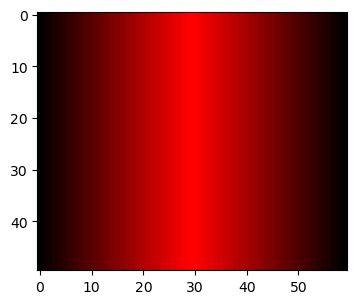

In [13]:
# red only
img = img_colab.copy()

img[:, :, 1] = 0
img[:, :, 2] = 0

print(img)
show_image(img)

(3648, 2052, 3)
[[[128 115  98]
  [130 117 100]
  [130 117 100]
  ...
  [191 177 150]
  [191 177 150]
  [190 176 149]]

 [[130 117 100]
  [129 116  99]
  [129 116  99]
  ...
  [193 179 152]
  [193 179 152]
  [191 177 150]]

 [[131 118 101]
  [129 116  99]
  [129 116  99]
  ...
  [193 179 152]
  [192 178 151]
  [190 176 149]]

 ...

 [[146 130 107]
  [146 130 107]
  [146 130 107]
  ...
  [190 173 129]
  [174 156 110]
  [168 147 100]]

 [[146 130 107]
  [146 130 107]
  [146 130 107]
  ...
  [192 176 125]
  [174 158 106]
  [168 151  95]]

 [[147 131 108]
  [147 131 108]
  [146 130 107]
  ...
  [194 180 131]
  [183 167 115]
  [181 164 108]]]


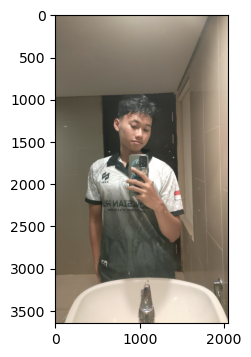

In [14]:
real_image = plt.imread("image.jpg")
# plt.imread mengembalikan value #* (0 - 255) untuk .jpg
# plt.imread mengembalikan value #* (0 - 1) untuk .png

print(real_image.shape)
print(real_image)
show_image(real_image)

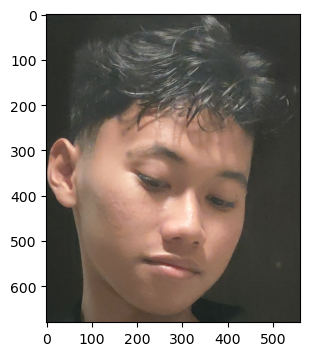

In [15]:
img = real_image.copy()

crop = img[950:1630, 690:1250]

show_image(crop)

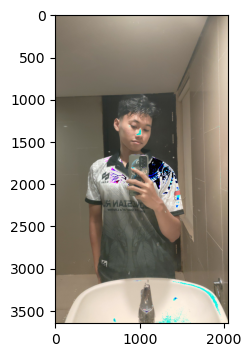

In [16]:
img = real_image.copy()
bright_img = img + 5

show_image(bright_img)

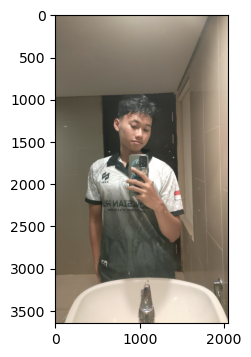

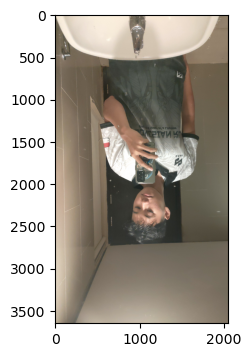

In [17]:
img = real_image.copy()

flip_img = img[::-1,::-1]

show_image(img)
show_image(flip_img)

(3648, 2052, 3) (3,)


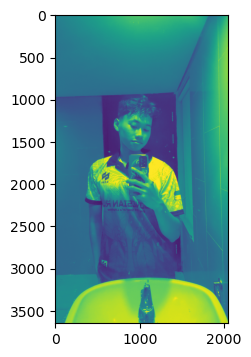

In [18]:
img = real_image.copy()

gray = np.array([0.299, 0.587, 0.114])
print(img.shape, gray.shape)

gray_img = img @ gray

show_image(gray_img)